In [2]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Autograd

In [3]:
# Requires_grad = True nhằm theo dõi để tính backprogation
x = torch.FloatTensor([5])
x.requires_grad = True

w = torch.FloatTensor([2])
w.requires_grad = True

b = torch.FloatTensor([3])
b.requires_grad = True

y = w * x + b
# y = 2*x+3

y.backward()
# Đạo hàm theo x = 2
# Đạo hàm theo w = 5
# Đạo hàm theo b = 1
# .item() là cách để chuyển tensor->scalar nôm na là chuyển từ tensor sang một dạng số
print('dx/dy=', x.grad.item())
print('dw/dy=', w.grad.item())
print('db/dy=', b.grad.item())

dx/dy= 2.0
dw/dy= 5.0
db/dy= 1.0


# Finding the minimum

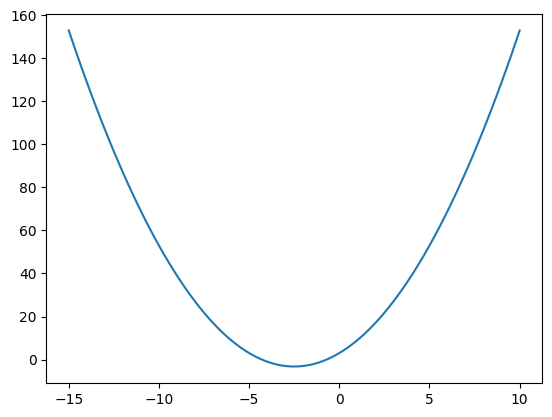

In [4]:
fx = lambda x: x**2+5*x+3
x = np.linspace(-15, 10, 100)
plt.plot(x, fx(x));

In [5]:
x_ = torch.randn(1)
x_.requires_grad = True

y = fx(x_)
y.backward()
print(f'dy/dx= {x_.grad.item()}, khi x={x_.item()}')

dy/dx= 1.3188588619232178, khi x=-1.8405705690383911


In [15]:
x_ = torch.randn(1)
x_.requires_grad = True

#Create logger
x_logger = []
y_logger = []

#Set learning rate
learning_rate = 0.01

#Count how many steps
counter = 0

#Khởi tạo đạo hàm dy/dx
dy_dx_ = 1000

#Khởi tạo số lần chạy backprogation
max_steps = 100

while np.abs(dy_dx_) > 0.001:
  #Tính fx
  y_ = fx(x_)

  #Tính backprogation
  y_.backward()
  dy_dx_ = x_.grad.item()

  #Torch.no_grad() nhằm mục đích không tính toán backprogaton các thủ tục ở trong nhằm giảm chi phí
  with torch.no_grad():
    x_-=learning_rate*dy_dx_
    # grad.zero_() nhằm refresh gradient vì trong pytorch gradient sẽ được cộng dần
    x_.grad.zero_()
    # x.item() và y.item() nhằm lưu trữ giá trị x và y
    x_logger.append(x_.item())
    y_logger.append(y_.item())

  counter+=1
  if counter > max_steps:
    break

print(f'Y đạt giả trị nhỏ nhất = {y_.item()} khi x = {x_.item()} sau {counter} bước')

Y đạt giả trị nhỏ nhất = -3.1483259201049805 khi x = -2.1875133514404297 sau 101 bước


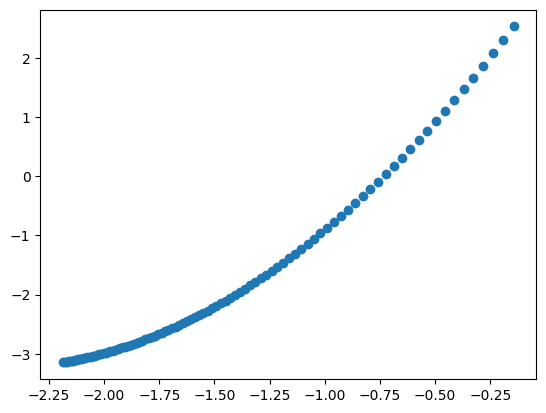

In [19]:
plt.plot(x_logger, y_logger, 'o');